In [1]:
import torch
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split

In [2]:
transform_train = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomRotation(10)
])

In [3]:
transforms_val = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


In [4]:
dataset_root = r"E:\\Pytorch_ML\\Major\\dataset\\test_set"
full_dataset = ImageFolder(root=dataset_root)

total = len(full_dataset)
train_size = int(0.7 * total)
val_size = int(0.15 * total)
test_size = total - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size]
 )

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f'Train samples: {len(train_loader.dataset)}')
print(f'Validation samples: {len(val_loader.dataset)}')
print(f'Test samples: {len(test_loader.dataset)}')

Train samples: 1416
Validation samples: 303
Test samples: 304


In [5]:
import torch.nn as nn

# WHAT IS A CNN?
# A CNN has two parts:
#   1. Feature extractor — finds patterns (edges, fur, eyes) using filters
#   2. Classifier — uses those patterns to decide: cat or dog?

class CatDogCNN(nn.Module):
    def __init__(self):
        super(CatDogCNN, self).__init__()

        # --- FEATURE EXTRACTOR ---
        # Conv2d(in_channels, out_channels, kernel_size)
        # Think of each filter as a "pattern detector" sliding over the image
        # Layer 1 detects simple things: edges, colors
        # Layer 2 detects combinations: curves, textures
        # Layer 3 detects complex things: eye shapes, ear outlines

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # 3 channels (RGB) → 32 filters
            nn.ReLU(),                                    # ReLU: turns negatives to 0 (adds non-linearity)
            nn.MaxPool2d(2, 2),                          # shrinks image by half (keeps strongest signal)

            nn.Conv2d(32, 64, kernel_size=3, padding=1), # 32 → 64 filters (learning more patterns)
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),# 64 → 128 filters
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )

        # --- CLASSIFIER ---
        # After convolutions, flatten the 3D feature map into a 1D vector
        # Then use fully connected layers to make the final cat/dog decision

        self.classifier = nn.Sequential(
            nn.Flatten(),                    # 128 × 16 × 16 = 32768 values in a row
            nn.Linear(128 * 16 * 16, 256),  # 32768 inputs → 256 neurons
            nn.ReLU(),
            nn.Dropout(0.5),                 # randomly turns off 50% neurons during training
                                             # WHY? Prevents the model from relying on one neuron too much
            nn.Linear(256, 1),              # 256 → 1 output (single score)
            nn.Sigmoid()                    # squashes output to 0.0–1.0 (probability of being a dog)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = CatDogCNN()
print(model)

CatDogCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


In [6]:
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split

# Transforms
transform_train = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

transform_val = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Load datasets WITH transforms this time
train_dataset = ImageFolder(r"E:\\Pytorch_ML\\Major\\dataset\\test_set",
                            transform=transform_train)  # ← transform here!

test_dataset  = ImageFolder(r"E:\\Pytorch_ML\\Major\\dataset\\test_set",
                            transform=transform_val)    # ← transform here!

# Split training into train + validation
val_size   = int(0.15 * len(train_dataset))
train_size = len(train_dataset) - val_size
train_set, val_set = random_split(train_dataset, [train_size, val_size])

# Give val_set the val transform (no augmentation)
val_set.dataset.transform = transform_val

# Create loaders
train_loader = DataLoader(train_set,    batch_size=32, shuffle=True)
val_loader   = DataLoader(val_set,      batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Train: {train_size} | Val: {val_size} | Test: {len(test_dataset)}")

Train: 1720 | Val: 303 | Test: 2023


In [7]:
import torch.optim as optim

# Set device: use GPU if available, else CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# WHY BCELoss? Binary Cross Entropy — measures how wrong the model's probability is
# If true label is 1 (dog) and model says 0.9 → small loss (good!)
# If true label is 1 (dog) and model says 0.1 → large loss (bad!)
criterion = nn.BCELoss()

# Adam optimizer: automatically adjusts learning speed for each weight
optimizer = optim.Adam(model.parameters(), lr=0.001)

def train_model(model, epochs=15):
    train_losses, val_losses = [], []
    train_accs,   val_accs   = [], []

    for epoch in range(epochs):
        # --- TRAINING PHASE ---
        model.train()  # tells layers like Dropout: "we are training now"
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)  # shape: [32, 1]

            optimizer.zero_grad()        # clear old gradients (important!)
            outputs = model(images)      # forward pass: model makes predictions
            loss = criterion(outputs, labels)  # compare predictions to truth
            loss.backward()              # backward pass: compute gradients
            optimizer.step()             # update weights using gradients

            running_loss += loss.item()
            predicted = (outputs > 0.5).float()  # threshold: >0.5 = dog, else cat
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc  = correct / total

        # --- VALIDATION PHASE ---
        model.eval()   # tells Dropout: "freeze, we are evaluating now"
        val_loss_total, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():  # don't compute gradients (saves memory)
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.float().unsqueeze(1).to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss_total += loss.item()
                predicted = (outputs > 0.5).float()
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_loss_total / len(val_loader)
        val_acc  = val_correct / val_total

        train_losses.append(train_loss); val_losses.append(val_loss)
        train_accs.append(train_acc);   val_accs.append(val_acc)

        print(f"Epoch {epoch+1:2d}/{epochs} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    return train_losses, val_losses, train_accs, val_accs

train_losses, val_losses, train_accs, val_accs = train_model(model, epochs=15)

Epoch  1/15 | Train Loss: 0.7365 Acc: 0.5087 | Val Loss: 0.6925 Acc: 0.4917
Epoch  2/15 | Train Loss: 0.6899 Acc: 0.5390 | Val Loss: 0.6929 Acc: 0.4851
Epoch  3/15 | Train Loss: 0.6648 Acc: 0.6052 | Val Loss: 0.6787 Acc: 0.6403
Epoch  4/15 | Train Loss: 0.5998 Acc: 0.6756 | Val Loss: 0.6559 Acc: 0.6106
Epoch  5/15 | Train Loss: 0.5476 Acc: 0.7099 | Val Loss: 0.6375 Acc: 0.6502
Epoch  6/15 | Train Loss: 0.4919 Acc: 0.7552 | Val Loss: 0.7287 Acc: 0.6403
Epoch  7/15 | Train Loss: 0.4096 Acc: 0.8140 | Val Loss: 0.6936 Acc: 0.6634
Epoch  8/15 | Train Loss: 0.3160 Acc: 0.8599 | Val Loss: 0.8261 Acc: 0.6634
Epoch  9/15 | Train Loss: 0.2105 Acc: 0.9087 | Val Loss: 1.0746 Acc: 0.6733
Epoch 10/15 | Train Loss: 0.1430 Acc: 0.9436 | Val Loss: 2.1570 Acc: 0.6601
Epoch 11/15 | Train Loss: 0.1155 Acc: 0.9576 | Val Loss: 1.6210 Acc: 0.6205
Epoch 12/15 | Train Loss: 0.0495 Acc: 0.9860 | Val Loss: 2.5195 Acc: 0.6403
Epoch 13/15 | Train Loss: 0.0466 Acc: 0.9860 | Val Loss: 2.4730 Acc: 0.6502
Epoch 14/15 

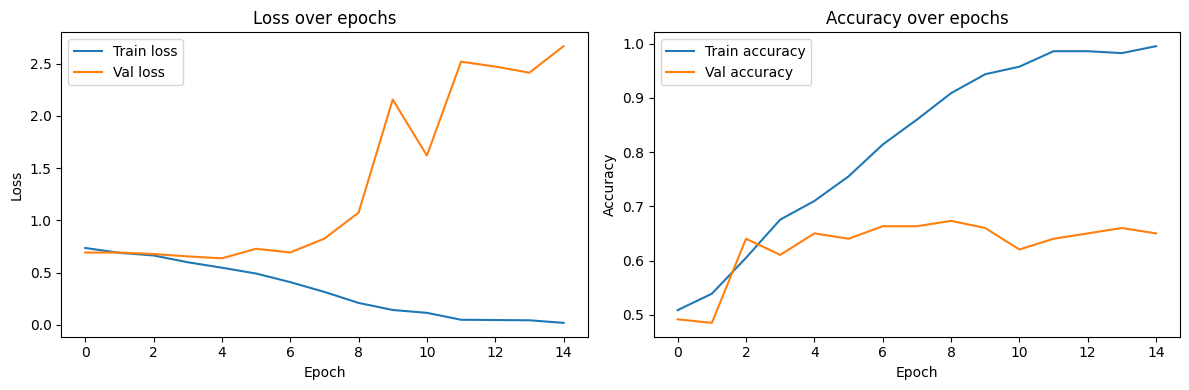

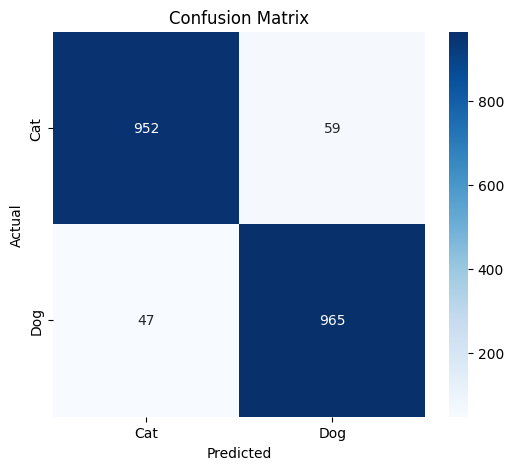

              precision    recall  f1-score   support

         Cat       0.95      0.94      0.95      1011
         Dog       0.94      0.95      0.95      1012

    accuracy                           0.95      2023
   macro avg       0.95      0.95      0.95      2023
weighted avg       0.95      0.95      0.95      2023

Accuracy: 0.9476


In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

# --- PLOT TRAINING CURVES ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label='Train loss')
ax1.plot(val_losses,   label='Val loss')
ax1.set_title('Loss over epochs')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(train_accs, label='Train accuracy')
ax2.plot(val_accs,   label='Val accuracy')
ax2.set_title('Accuracy over epochs')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.savefig('training_curves.png')
plt.show()

# --- CONFUSION MATRIX & REPORT on TEST set ---
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        predicted = (outputs > 0.5).float().squeeze().cpu().numpy()
        all_preds.extend(predicted)
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# Confusion matrix
# Rows = actual labels, Columns = predicted labels
# [TN  FP]   TN = correctly said "cat"
# [FN  TP]   TP = correctly said "dog"
#            FP = wrongly said "dog" (it was a cat)
#            FN = wrongly said "cat" (it was a dog)
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cat', 'Dog'],
            yticklabels=['Cat', 'Dog'])
plt.title('Confusion Matrix')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.savefig('confusion_matrix.png')
plt.show()

# Full report: precision, recall, F1
print(classification_report(all_labels, all_preds, target_names=['Cat', 'Dog']))

# accuracy
accuracy = (cm[0, 0] + cm[1, 1]) / np.sum(cm)
print(f'Accuracy: {accuracy:.4f}')